In [4]:
import matplotlib.pyplot as plt
import numpy as np
from ilipy import  Session
from ilipy.database import DistanceCorrelation
from rnd.utils.data_utils import (
    set_ili_run,
    #extract_arm_angles,
    #create_arm_array,
)

In [5]:
run_number = 6
_, _, inspection_id, env, _, start_dist, end_dist = set_ili_run(run_number)
session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

PySettings.cpp(46): ilipy: Build 0.17.2.10867 5d2ea142f2 release-ili-0.17 'Tue Jul 22 21:50:18 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(168): WebSoc

In [6]:
import pandas as pd
from typing import Dict
from ilipy.sensors import ArmAngleLookup
from ilipy import ClipTypes, OdometerTicks, OdometerTickRange, ViewDistance

def extract_arm_angles(
    session, dist_corr, view_distance_range_m, tick_sampling_interval=10
):

    all_arms = {}
    clips = session.get_clips_by_type(ClipTypes.ChannelData)

    start_vd, end_vd = view_distance_range_m

    for clip in clips:
        # 1) map view-distances -> odometer-ticks for this clip
        try:
            tick_start = dist_corr.get_odometer_ticks_from_view_distance(
                clip, ViewDistance(start_vd)
            )
            tick_end = dist_corr.get_odometer_ticks_from_view_distance(
                clip, ViewDistance(end_vd)
            )
        except Exception:
            continue  # clip can’t map those distances

        query_range = OdometerTickRange(tick_start, tick_end)
        clip_range = clip.odometer_tick_range

        # 2) skip clips with no raw-tick overlap
        if (
            clip_range.max.value < query_range.min.value
            or clip_range.min.value > query_range.max.value
        ):
            continue

        # 3) clamp to the actual overlapping integer ticks
        lo = max(clip_range.min.value, tick_start.value)
        hi = min(clip_range.max.value, tick_end.value)
        if hi <= lo:
            continue

        # 4) sample every tick_sampling_interval ticks
        arm_lookup = ArmAngleLookup(session, clip)
        rows = []
        for tick in range(int(lo), int(hi) + 1, tick_sampling_interval):
            odot = OdometerTicks(tick)
            angle = arm_lookup.get_axis_angle_from_odometer_ticks(odot)
            # vd_m = dist_corr.get_view_distance_from_odometer_ticks(clip, odot).value
            rows.append(
                {
                    "track_index": clip.track_index,
                    # "odometer_tick": tick,
                    # "view_distances_m": vd_m,
                    "arm_axis_angles_rad": angle,
                }
            )

        # 5) only keep clips where we actually got samples
        if rows:
            all_arms[clip.clip_id] = pd.DataFrame(rows)

    return all_arms

def create_arm_array(
    arm_data_dict: Dict[str, pd.DataFrame],
    arm_data_samples: Dict[str, pd.DataFrame]=None,
    num_tracks: int = 20,
    num_tick_samples: int = 500,
    normalize: bool = False,
) -> np.ndarray:
    all_dfs = pd.concat(arm_data_dict.values(), ignore_index=True)
    grouped = all_dfs.groupby("track_index")["arm_axis_angles_rad"]
    groups = {track_idx: group.values for track_idx, group in grouped}

    arm_array = np.zeros((num_tracks, num_tick_samples), dtype=np.float32)

    for i in range(num_tracks):
        if i in groups:
            values = groups[i]
            length = min(num_tick_samples, len(values))
            arm_array[i, :length] = values[:length]
            if length < num_tick_samples and length > 0:
                arm_array[i, length:] = values[length - 1]

    if normalize == "range":
        all_dfs_sample = pd.concat(arm_data_samples.values(), ignore_index=True)
        grouped_sample = all_dfs_sample.groupby("track_index")["arm_axis_angles_rad"]
        groups_sample = {track_idx: group.values for track_idx, group in grouped_sample}
        q1 = np.zeros(num_tracks, dtype=np.float32)
        q99 = np.zeros(num_tracks, dtype=np.float32)

        for i in range(num_tracks):
            if i in groups_sample:
                
                q1[i] = np.percentile(groups_sample[i], 1)
                q99[i] = np.percentile(groups_sample[i], 99)
                arm_array[i, :] = np.clip(
                    arm_array[i, :],
                    q1[i],
                    q99[i],
                )

        q99 = q99.reshape(-1, 1) 
        q1 = q1.reshape(-1, 1) 
        denom = np.where((q99 - q1) == 0, 1, q99 - q1)
        arm_array = (arm_array - q1) / denom
        return arm_array
    elif normalize == "patch":
           
            row_min = arm_array.min(axis=1, keepdims=True)
            row_max = arm_array.max(axis=1, keepdims=True)
            denom = np.where((row_max - row_min) == 0, 1, row_max - row_min)
            arm_array = (arm_array - row_min) / denom
    return arm_array

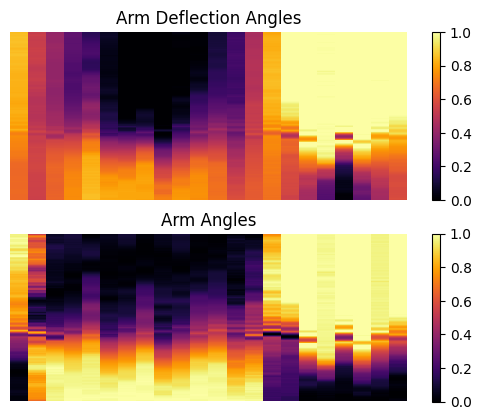

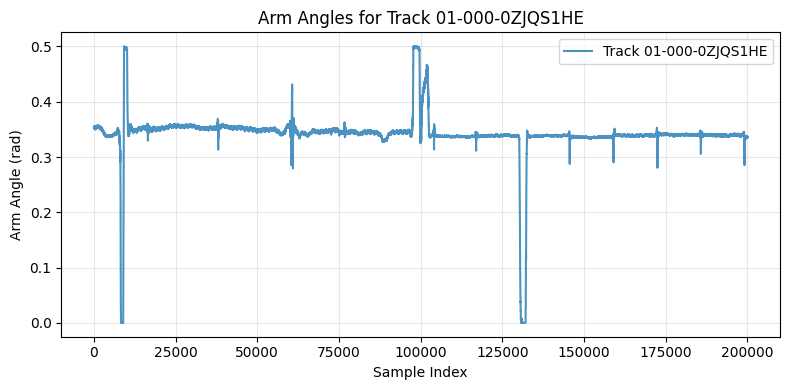

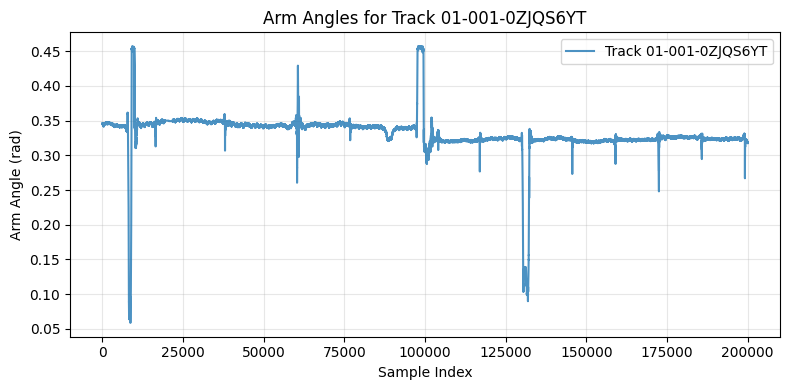

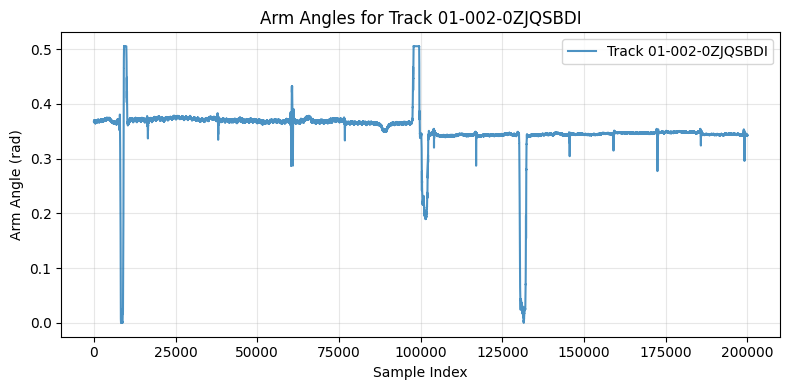

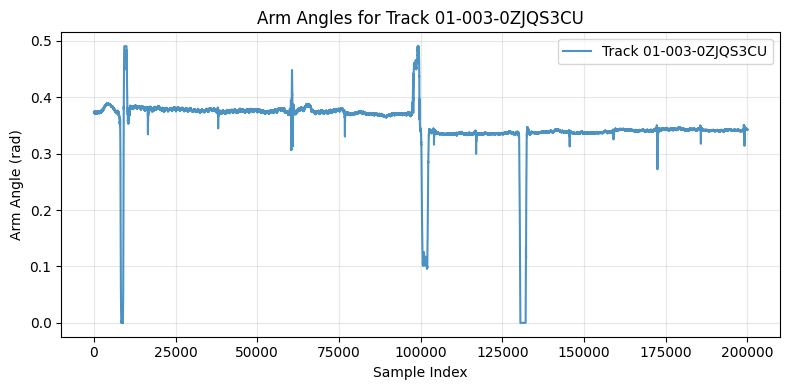

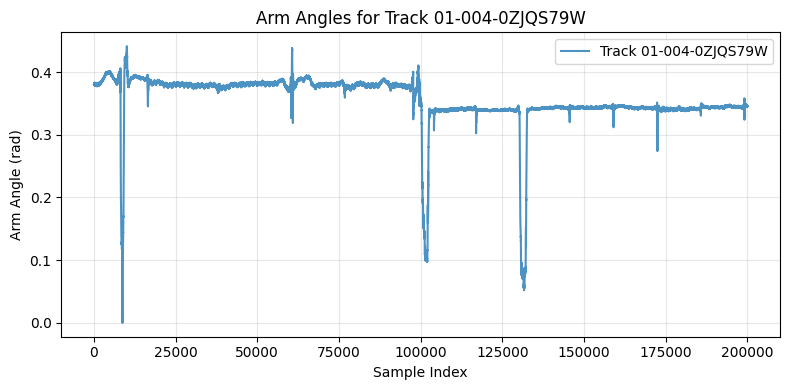

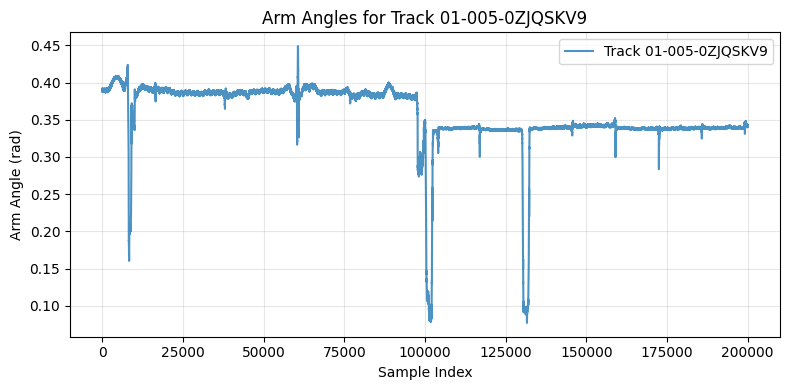

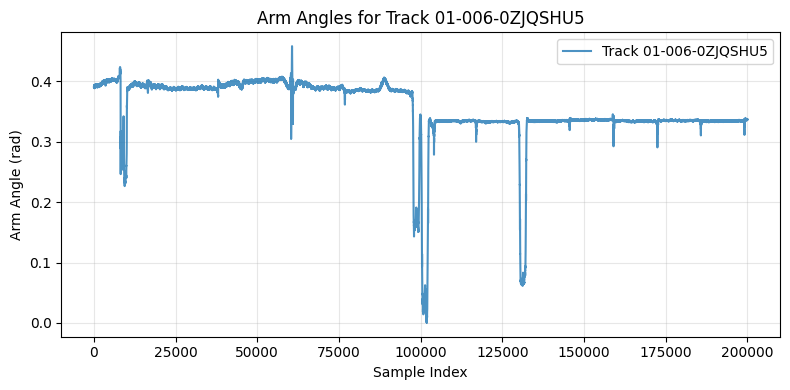

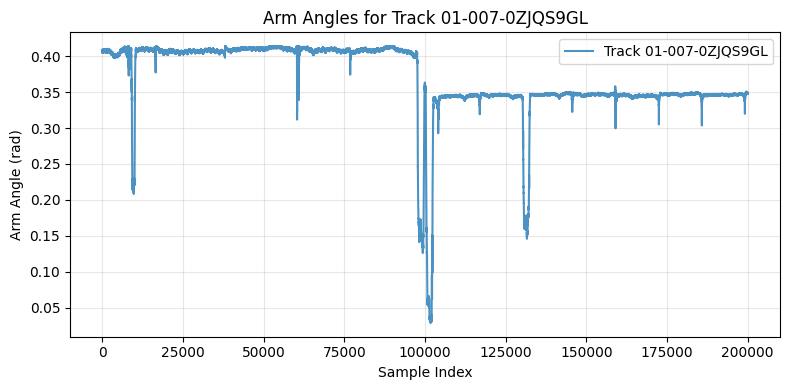

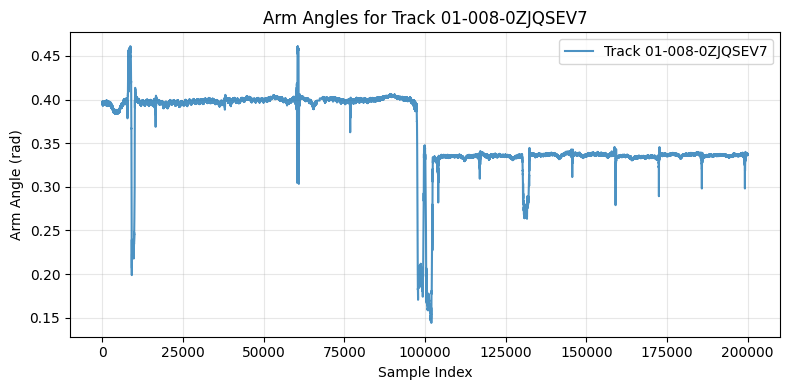

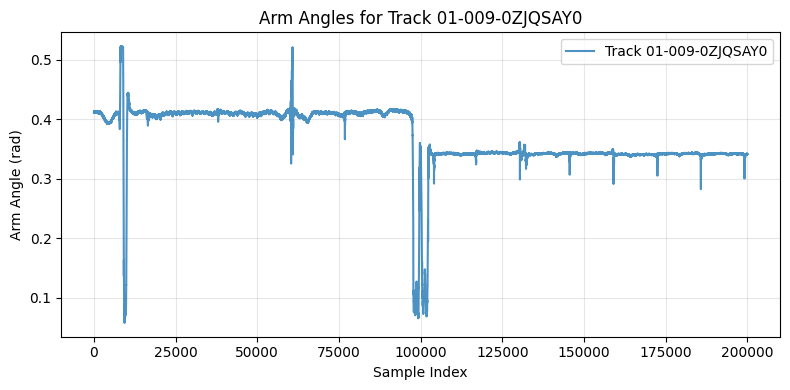

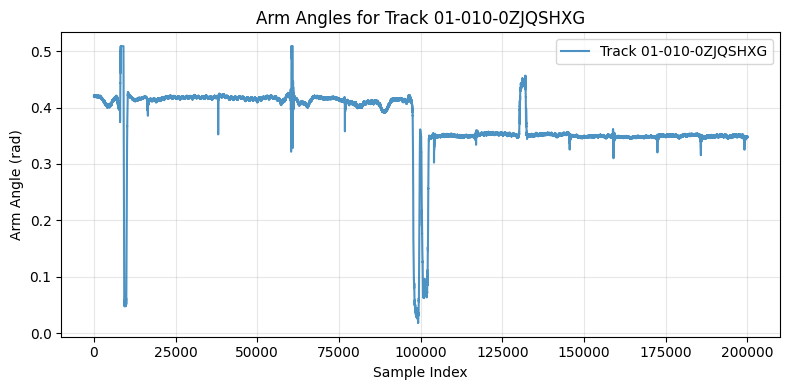

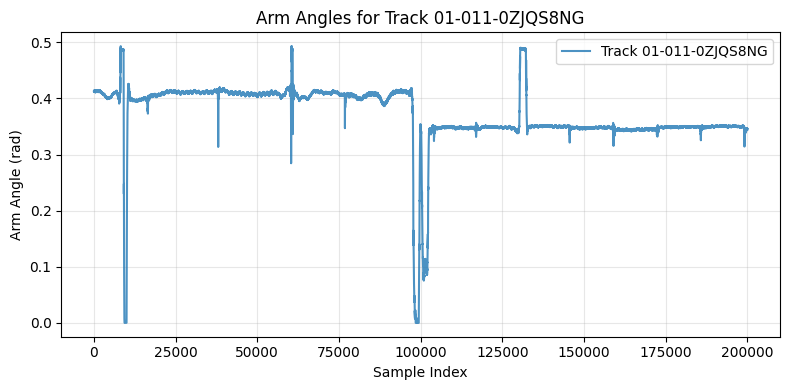

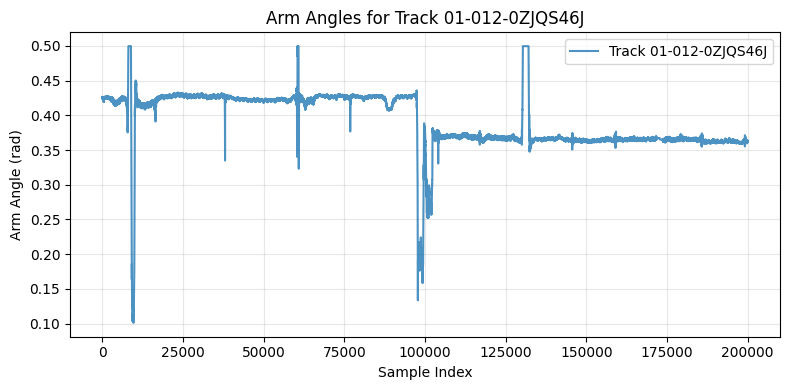

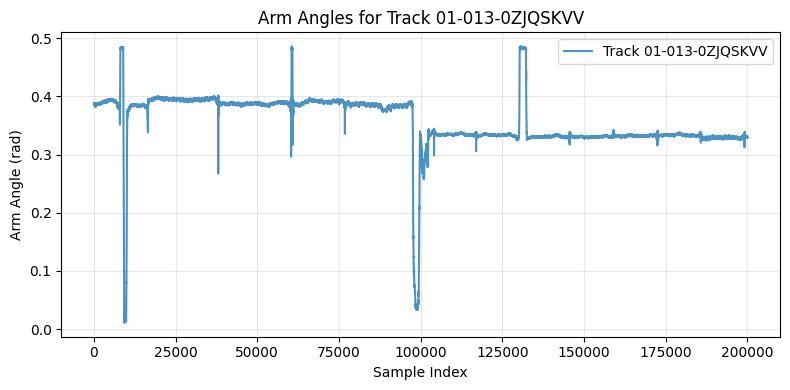

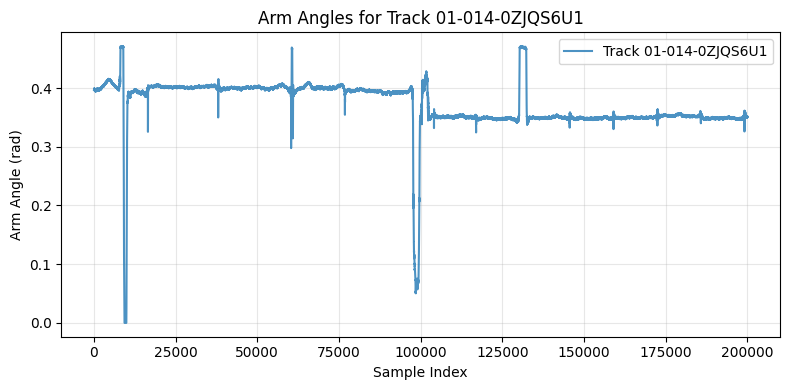

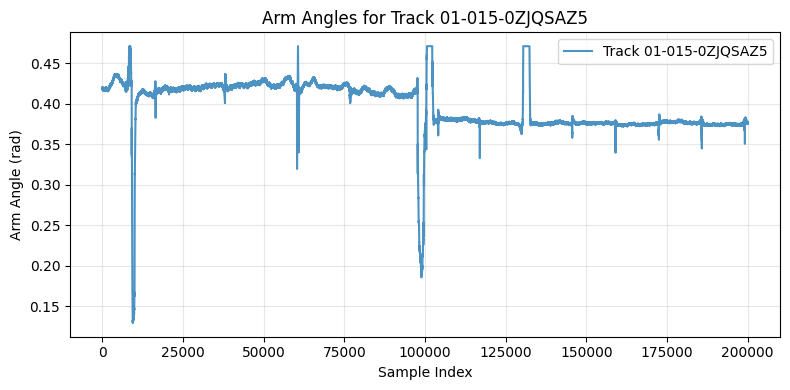

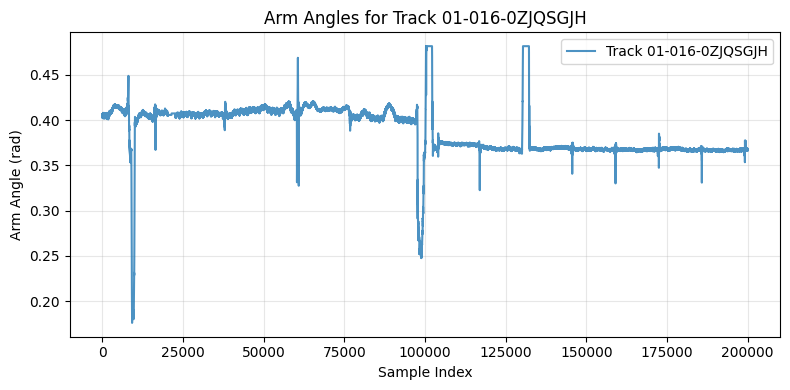

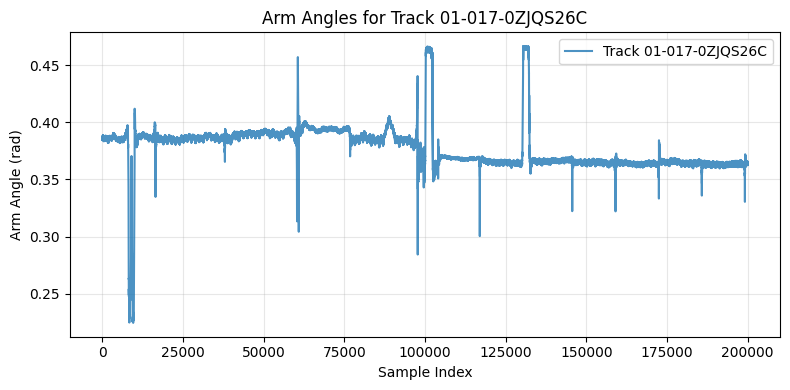

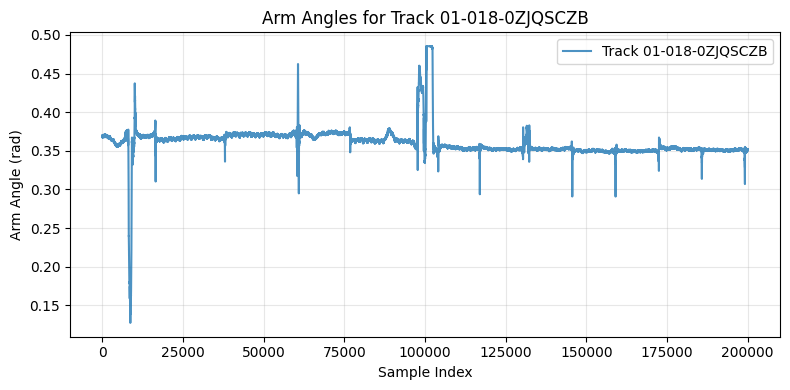

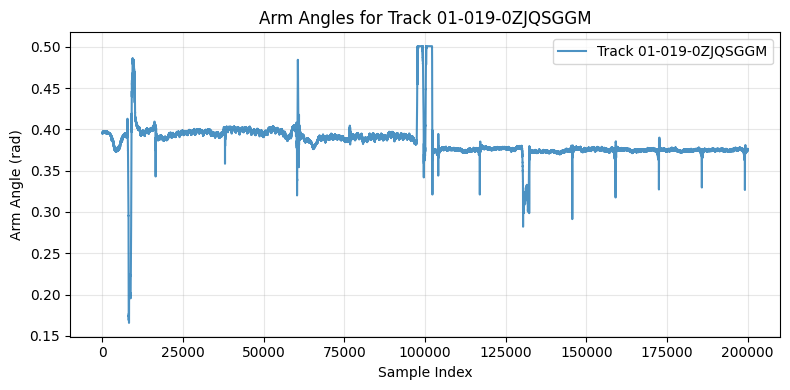

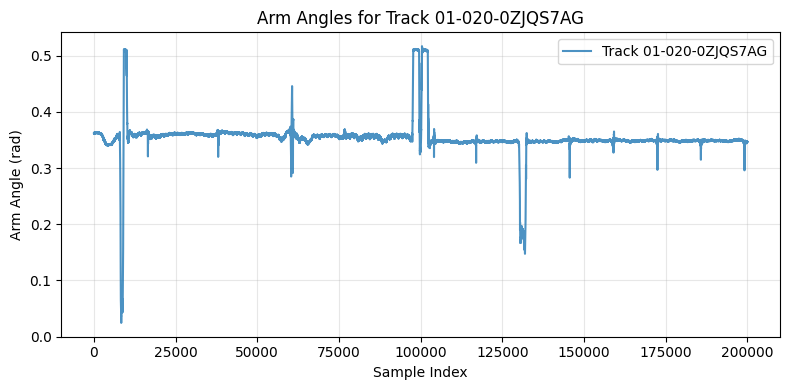

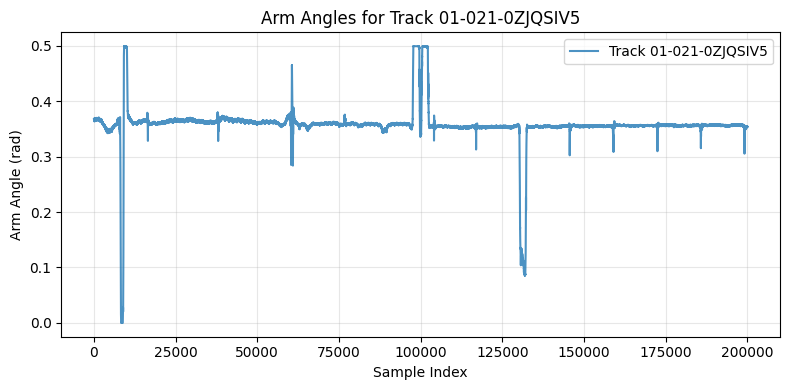

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: 

In [ ]:
def min_max_normalize(arr):
    arr_min = arr.min(axis=1, keepdims=True)
    arr_max = arr.max(axis=1, keepdims=True)
    denom = np.where((arr_max - arr_min) == 0, 1, arr_max - arr_min)
    return (arr - arr_min) / denom

def z_normalize(arr, axis=None):
    arr_mean = arr.mean(axis=axis, keepdims=True)
    arr_std = arr.std(axis=axis, keepdims=True)
    return (arr - arr_mean) / np.where(arr_std == 0, 1, arr_std)

def moving_average(x, window_size=100):
    return np.convolve(x, np.ones(window_size)/window_size, mode='same')

view_dist = 652.3 -0.15
length = 1
img_range = (view_dist, view_dist + length)
tick_sampling_interval = 10

arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
arm_angles_samples = extract_arm_angles(session=session, dist_corr=dist_corr,
    view_distance_range_m=(
        view_dist - 200/ 2,
        view_dist + 200 / 2,
    ),
    tick_sampling_interval=tick_sampling_interval,
)
num_tick_samples = int(length * 10000 / tick_sampling_interval)
img_patch = create_arm_array(
    arm_angles, arm_data_samples=arm_angles_samples,
    num_tracks=22,
    num_tick_samples=num_tick_samples,
    normalize="patch",
)
img_range = create_arm_array(
    arm_angles, arm_data_samples=arm_angles_samples,
    num_tracks=22,
    num_tick_samples=num_tick_samples,
    normalize="range",
)

#img_s = np.apply_along_axis(moving_average, 1, img, window_size=3)
img_norm = min_max_normalize(img_patch)

img_z1 = z_normalize(img_norm)
img_z2 = z_normalize(img_patch, axis=1)
img_z3 = z_normalize(img_z2)

# row_diffs = np.diff(img, axis=0, n=0)
# row_diffs_norm = min_max_normalize(row_diffs)
# row_diffs_z = z_normalize(row_diffs_norm)




plt.subplot(2, 1, 1)
plt.imshow(
    img_range.T, cmap="inferno", origin="lower", aspect="auto",
    interpolation="nearest",vmin=0, vmax=1
)
plt.axis("off")
plt.colorbar()
plt.title("Arm Deflection Angles")

plt.subplot(2, 1, 2)
plt.imshow(
    img_patch.T, cmap="inferno", origin="lower", aspect="auto",
    interpolation="nearest",
)
plt.axis("off")
plt.colorbar()
plt.title("Arm Angles")
plt.show()
plt.close()

#plot arm samples per track independently


for k, v in arm_angles_samples .items():
    plt.figure(figsize=(8, 4))
    plt.plot(v["arm_axis_angles_rad"], label=f"Track {k}", alpha=0.8)
    plt.xlabel("Sample Index")
    plt.ylabel("Arm Angle (rad)")
    plt.title(f"Arm Angles for Track {k}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

